# Inter-Node Analysis

This notebook loads a benchmark's capability tree and computes the Kendall's Tau between each node's local model ranking and the global model ranking.

Import packages.

In [47]:
import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict
from scipy.stats import kendalltau, rankdata
from tqdm import tqdm
from src.utils.capability_tree import (
    align_rankings,
    collect_nodes,
    load_capability_tree,
)
from src.utils.enums import Dataset
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

Specify the benchmark, load it's capability tree, and collect the tree's nodes.

In [48]:
dataset = Dataset.MMLU
root = load_capability_tree(dataset)

Collect the capability tree's nodes.

In [49]:
min_instances = 0
global_ranking = root["ranking"]
nodes = collect_nodes(root, min_instances)

num_models = len(global_ranking)
print(f"Number of models: {num_models}")
print(f"Found {len(nodes)} nodes (non-root, size > {min_instances} instances)")

Number of models: 9
Found 22207 nodes (non-root, size > 0 instances)


### Model Ranking Analysis

Compute the Kendall's Tau between each node's local model ranking and the global model ranking.

In [50]:
taus = []

kwargs = {
    "desc": "Computing Kendall's Taus",
    "total": len(nodes),
    "unit": "node",
}

for node in tqdm(nodes, **kwargs):
    if node["ranking"] is None:
        continue
    aligned_global_ranking, aligned_local_ranking = align_rankings(
        global_ranking, node["ranking"]
    )
    tau, _ = kendalltau(aligned_global_ranking, aligned_local_ranking)
    taus.append(tau)

Computing Kendall's Taus: 100%|██████████| 22207/22207 [00:04<00:00, 5194.67node/s]


Plot a histogram of the Kendall's Taus across the capability tree's nodes.

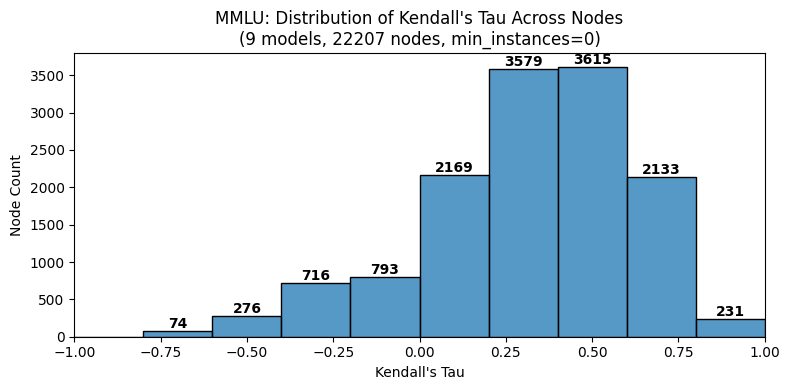

In [51]:
# Compute mean and std
taus_array = np.array(taus)
mean_tau = taus_array.mean()
std_tau = taus_array.std()

xlabel = "Kendall's Tau"
ylabel = "Node Count"
title = (
    f"{dataset}: Distribution of Kendall's Tau Across Nodes"
    f"\n({num_models} models, {len(nodes)} nodes, min_instances={min_instances})"
)
annotate = True
xlim = (-1, 1)

plot_histogram(
    taus_array,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    annotate=annotate,
    mean=mean_tau,
    std=std_tau,
    xlim=xlim,
)

analysis = "inter_node_analysis"
sub_analysis = "model_ranking"
plot_name = f"kendall_tau_distribution-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
plt.savefig(plot_path)
plt.show()

Create a bar chart that shows each model's standard deviation in rank across all nodes.

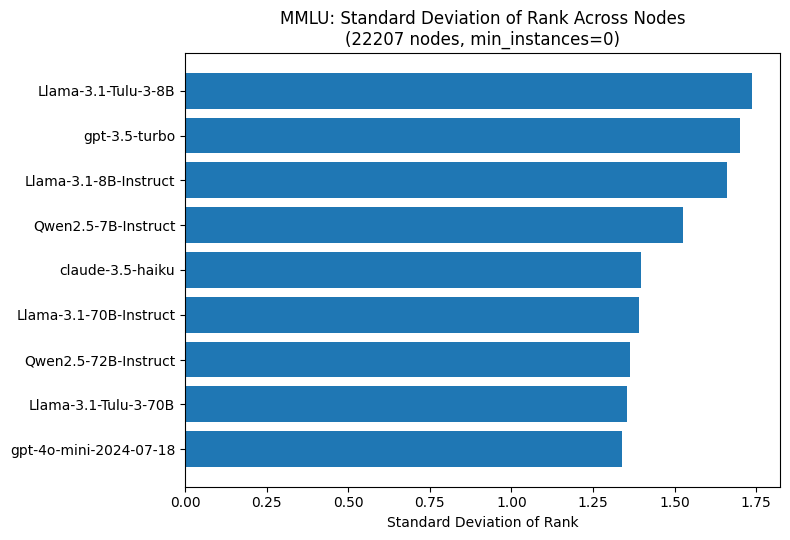

In [52]:
models = [model for model, _ in global_ranking]

model_node_ranks = defaultdict(list)
for node in nodes:
    if node["ranking"] is None:
        continue
    node_models = [m for m, _ in node["ranking"]]
    node_scores = np.array([s for _, s in node["ranking"]])
    ranks = rankdata(-node_scores, method="average")
    for model, rank in zip(node_models, ranks):
        model_node_ranks[model].append(rank)

model_rank_stds = {model: np.std(model_node_ranks[model]) for model in models}
model_rank_stds = dict(sorted(model_rank_stds.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 1))
ax.barh(list(model_rank_stds.keys()), list(model_rank_stds.values()))
ax.set_xlabel("Standard Deviation of Rank")
ax.set_title(
    f"{dataset}: Standard Deviation of Rank Across Nodes"
    f"\n({len(nodes)} nodes, min_instances={min_instances})"
)
fig.tight_layout()

plot_name = f"all_models-rank_std-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
fig.savefig(plot_path)
plt.show()

### Model Performance Analysis

Plot the distribution of each model's performance across all nodes.

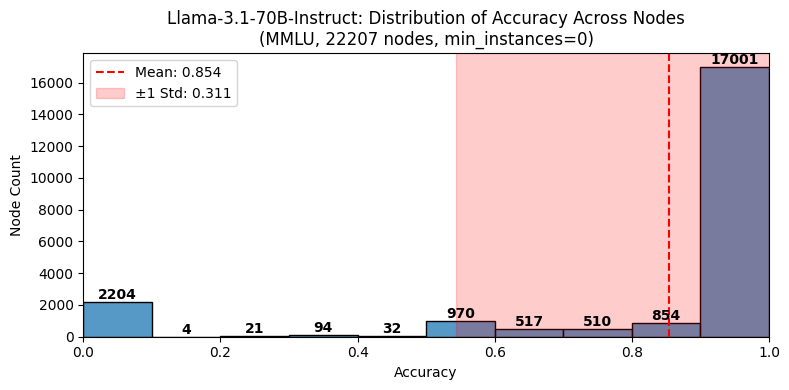

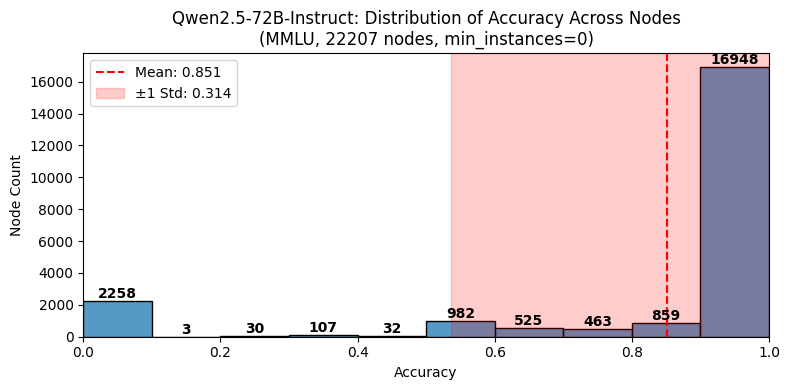

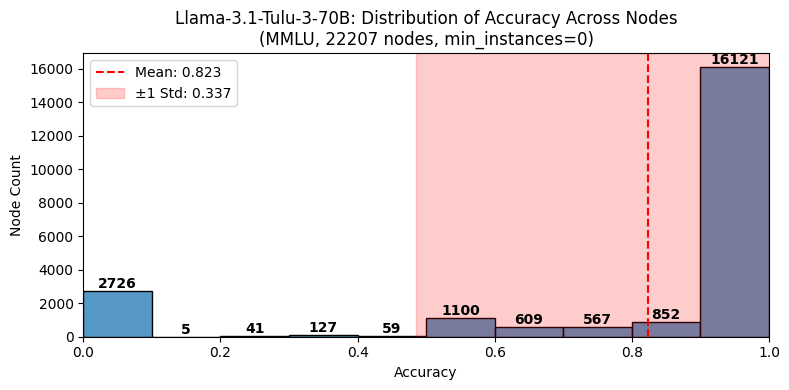

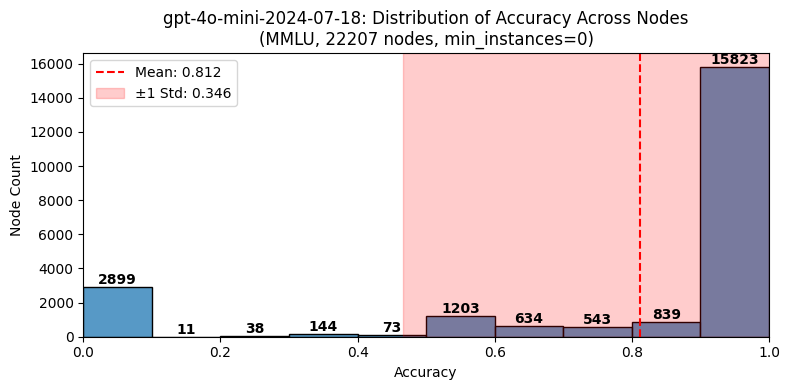

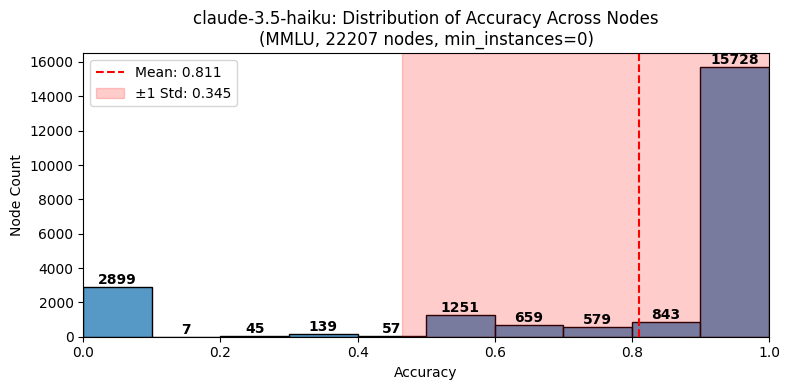

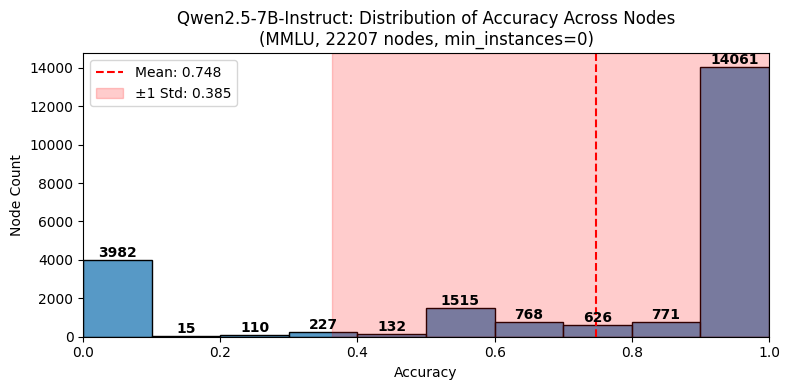

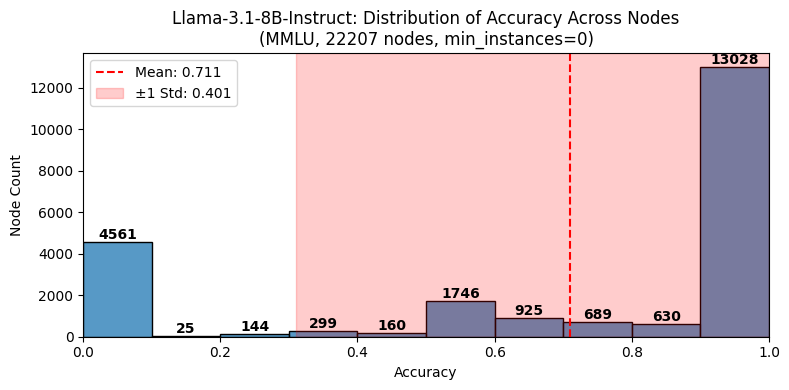

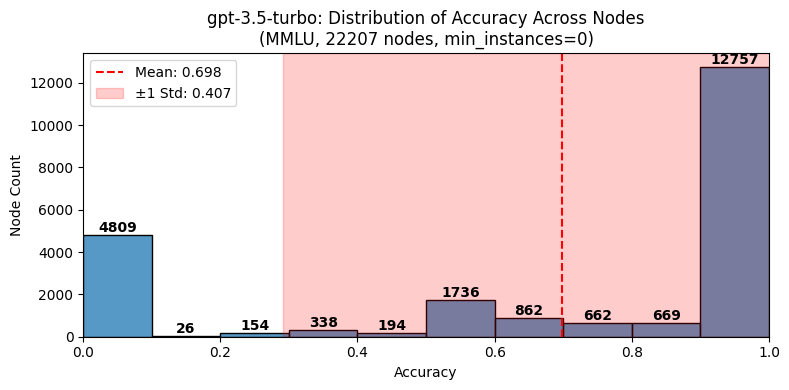

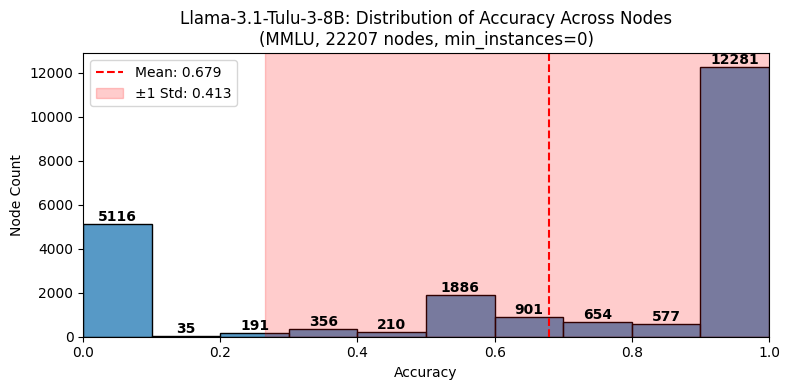

In [53]:
# Collect each model's accuracy scores across all nodes
model_scores = defaultdict(list)
for node in nodes:
    if node["ranking"] is None:
        continue
    for model, score in node["ranking"]:
        model_scores[model].append(score)


for model in models:
    scores = np.array(model_scores[model])
    metric = Dataset(dataset).metric
    xlabel = metric.capitalize()
    ylabel = "Node Count"
    title = (
        f"{model}: Distribution of {metric.capitalize()} Across Nodes"
        f"\n({dataset}, {len(nodes)} nodes, min_instances={min_instances})"
    )
    annotate = True
    mean = scores.mean()
    std = scores.std()
    xlim = (0, 1)

    fig = plot_histogram(
        scores,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        annotate=annotate,
        mean=mean,
        std=std,
        xlim=xlim,
    )

    plot_name = f"{model}-performance_distribution-min_instances={min_instances}"
    sub_analysis = "model_performance"
    plot_path = build_plot_path(
        dataset,
        analysis=analysis,
        sub_analysis=sub_analysis,
        plot_name=plot_name,
    )
    fig.savefig(plot_path)
    plt.show()

Create a bar chart that shows each model's standard deviation in performance across all nodes.

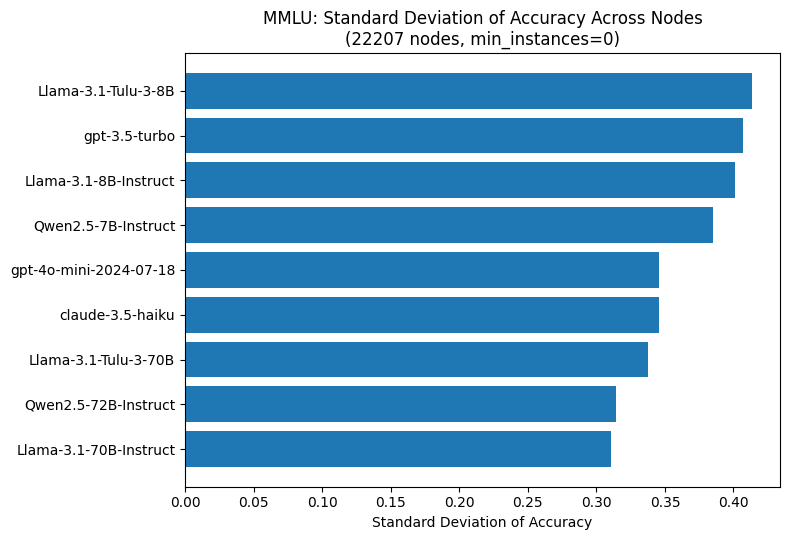

In [54]:
model_stds = {model: np.std(model_scores[model]) for model in models}
model_stds = dict(sorted(model_stds.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, len(models) * 0.5 + 1))
ax.barh(list(model_stds.keys()), list(model_stds.values()))
ax.set_xlabel(f"Standard Deviation of {metric.capitalize()}")
ax.set_title(
    f"{dataset}: Standard Deviation of {metric.capitalize()} Across Nodes"
    f"\n({len(nodes)} nodes, min_instances={min_instances})"
)
fig.tight_layout()

plot_name = f"all_models-performance_std-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    sub_analysis=sub_analysis,
    plot_name=plot_name,
)
fig.savefig(plot_path)
plt.show()